In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\DA\customer-churn-prediction\dataset\CustomerChurn.csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df = df.dropna()

In [7]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [10]:
# What % of customers churn?
df["Churn"].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [11]:
# Are high-paying customers leaving?
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

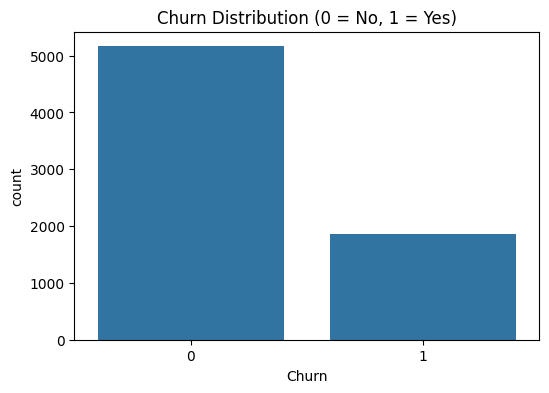

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution (0 = No, 1 = Yes)")
plt.show()

In [14]:
print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)


Churn Percentage:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


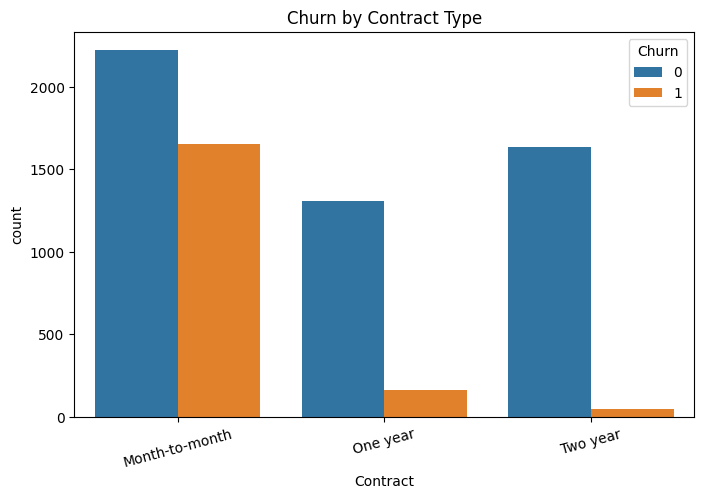

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

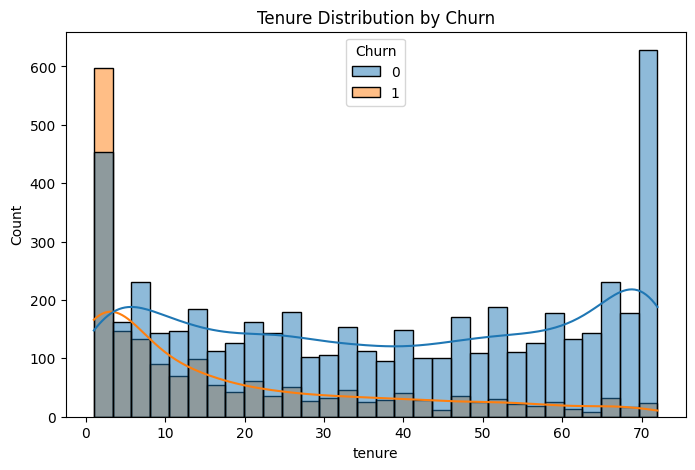

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

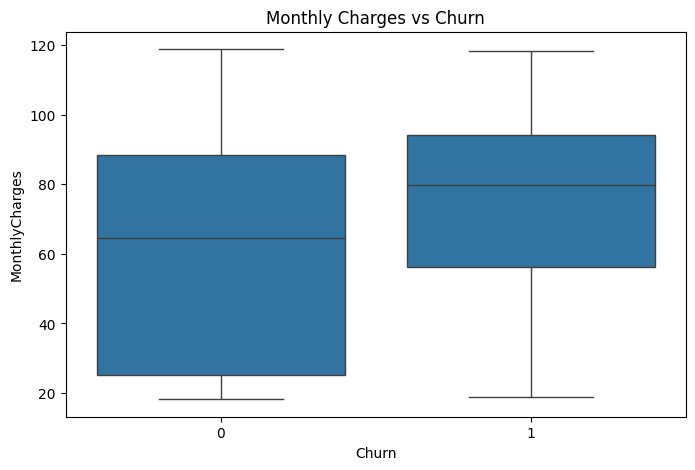

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges vs Churn")
plt.show()

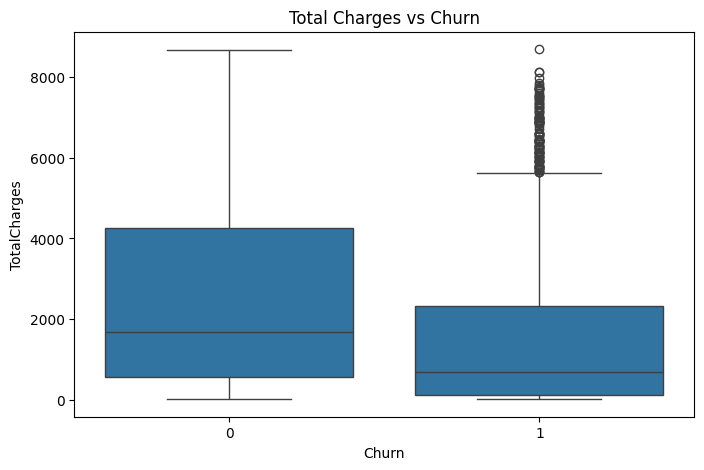

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title("Total Charges vs Churn")
plt.show()

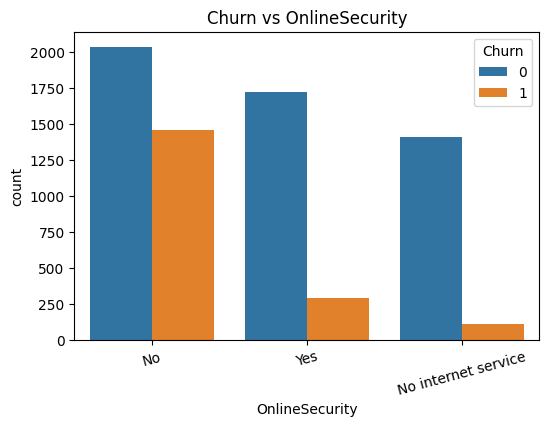

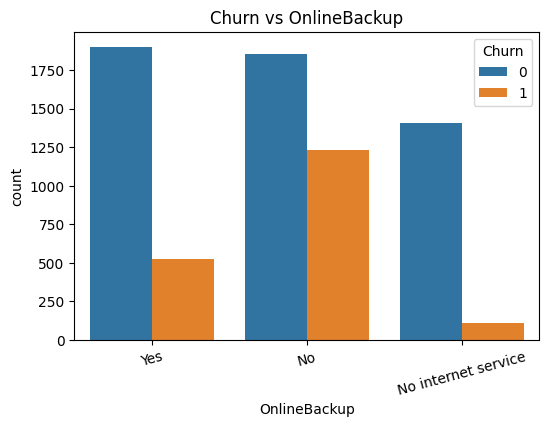

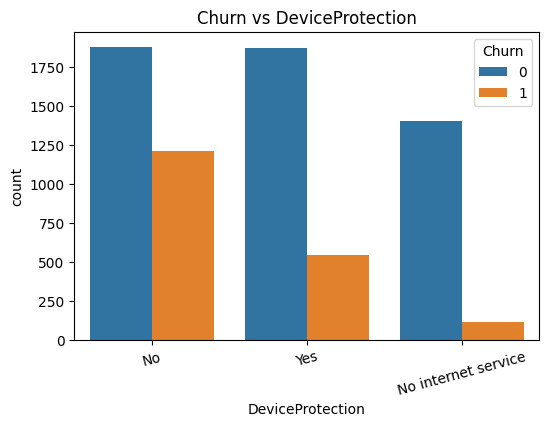

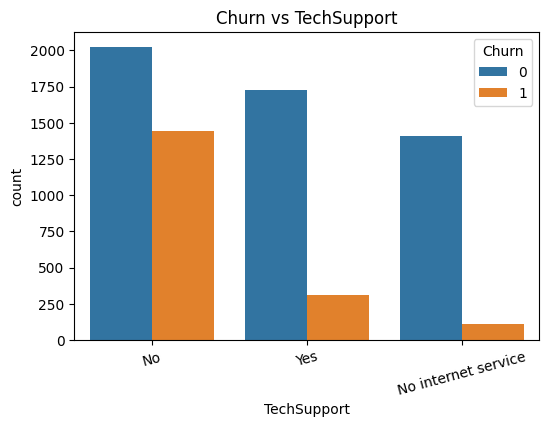

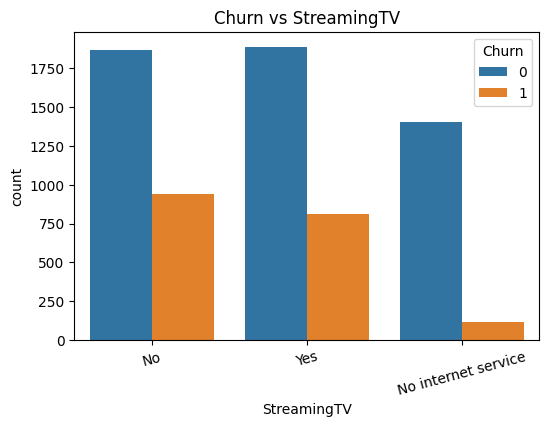

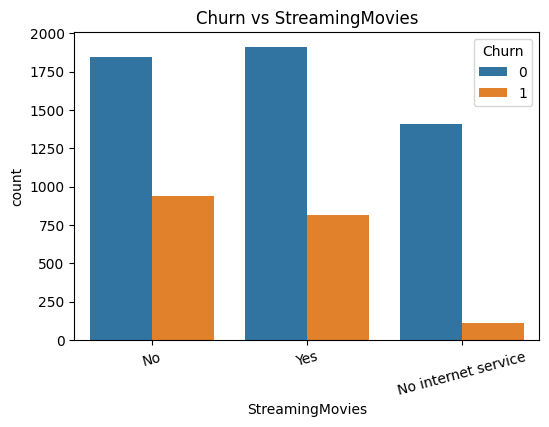

In [19]:
services = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for service in services:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=service, hue='Churn')
    plt.title(f"Churn vs {service}")
    plt.xticks(rotation=15)
    plt.show()

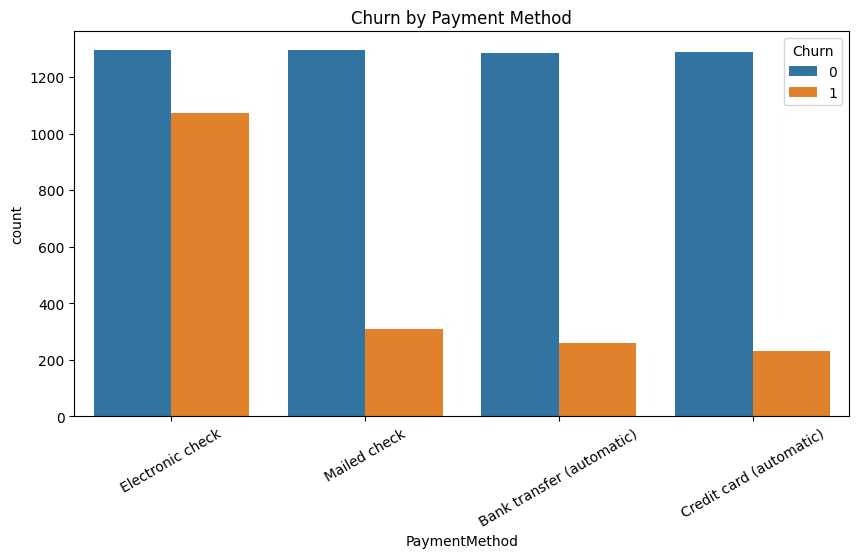

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title("Churn by Payment Method")
plt.xticks(rotation=30)
plt.show()

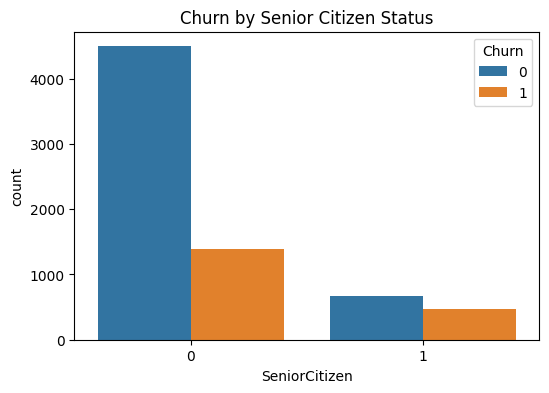

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.title("Churn by Senior Citizen Status")
plt.show()

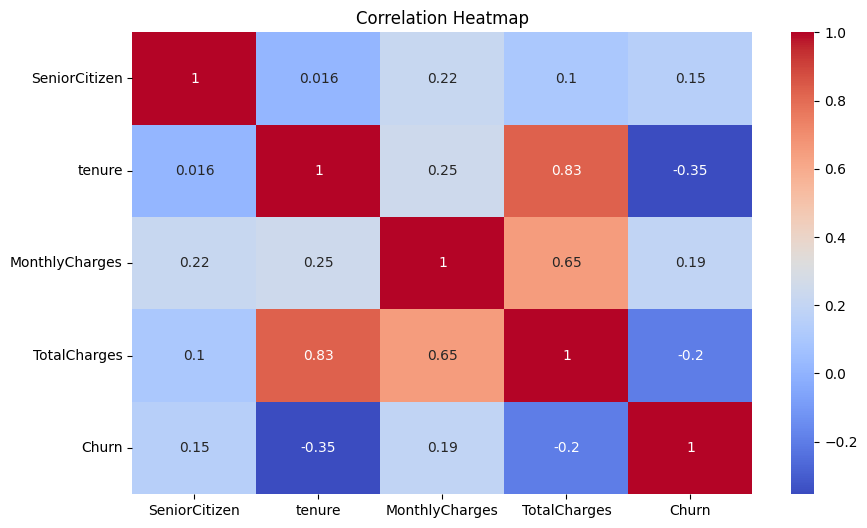

In [22]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

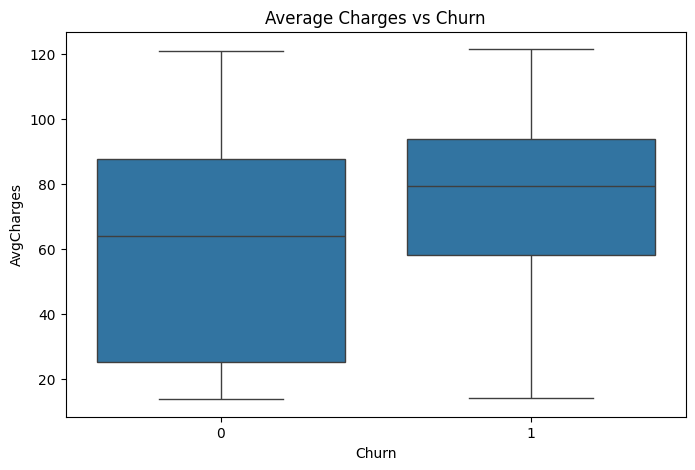

In [24]:
import numpy as np

df["AvgCharges"] = df["TotalCharges"] / df["tenure"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='AvgCharges')
plt.title("Average Charges vs Churn")
plt.show()